In this example, we show how to obtain a magnetic skyrmion using atomistic module in JuMag.
We import JuMag and use double float precision in the simulation.

In [1]:
using JuMag
using NPZ
JuMag.cuda_using_double(true)

We create a CubicMesh

In [2]:
mesh =  CubicMeshGPU(nx=120, ny=120, nz=1, pbc="xy")

CubicMeshGPU(1.0e-9, 1.0e-9, 1.0e-9, 120, 120, 1, 14400, 6, 12, 8, Int32[120 1 … 14398 14399; 2 3 … 14400 14281; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], true, true, false)

To start the simulation, we need to give an initial state.
We define a function in which we set the spins around site (60,60) to be negative

In [3]:
function m0_fun(i,j,k, dx, dy, dz)
  r2 = (i-60)^2 + (j-60)^2
  if r2 < 10^2
    return (0.1, 0, -1)
  end
  return (0,0,1)
end

m0_fun (generic function with 1 method)

We define a function to specify the problem.

In [4]:
function relax_system(mesh)
  #We create a simulation with 'SD' driver
  sim = Sim(mesh, driver="SD", name="skyrmion")

  #We set mu_s of the system
  set_mu_s(sim, 1.0)

  #Set the max step
  sim.driver.max_tau = 1.0

  #Set the exchange, dmi and zeeman
  add_exch(sim, 1.0, name="exch")
  add_zeeman(sim, (0,0,3.75e-3))
  add_dmi(sim, 0.09, name="dmi")

  #Initialize the system using the `m0_fun` function
  init_m0(sim, m0_fun)

  #Relax the system
  relax(sim, maxsteps=2000, stopping_dmdt=200)

  #Save the final magnetization state for later postprocessing
  npzwrite("skx.npy", Array(sim.spin))

  #Save the vtk as well
  save_vtk(sim, "skx", fields=["exch", "dmi"])
end

relax_system (generic function with 1 method)

Recall the function

In [5]:
relax_system(mesh)

[ Info: Running Driver : JuMag.EnergyMinimizationGPU{Float64}.
[ Info: step =    1  step_size=9.049774e-16    max_dmdt=4.633500e+04
[ Info: step =    2  step_size=6.341648e-06    max_dmdt=4.584287e+04
[ Info: step =    3  step_size=2.376731e-06    max_dmdt=1.069116e+05
[ Info: step =    4  step_size=8.548642e-06    max_dmdt=1.200619e+05
[ Info: step =    5  step_size=2.051240e-06    max_dmdt=2.220919e+05
[ Info: step =    6  step_size=2.766851e-06    max_dmdt=1.178625e+05
[ Info: step =    7  step_size=1.670407e-06    max_dmdt=8.987751e+04
[ Info: step =    8  step_size=3.518580e-06    max_dmdt=8.419246e+04
[ Info: step =    9  step_size=2.130563e-06    max_dmdt=6.986823e+04
[ Info: step =   10  step_size=4.113122e-06    max_dmdt=5.566571e+04
[ Info: step =   11  step_size=1.454606e-06    max_dmdt=7.277120e+04
[ Info: step =   12  step_size=1.665443e-06    max_dmdt=3.074096e+04
[ Info: step =   13  step_size=1.487158e-06    max_dmdt=2.773122e+04
[ Info: step =   14  step_size=9.049774e

1-element Vector{String}:
 "skx.vts"

After obtain the skyrmion, we use the following script to plot the skyrmion

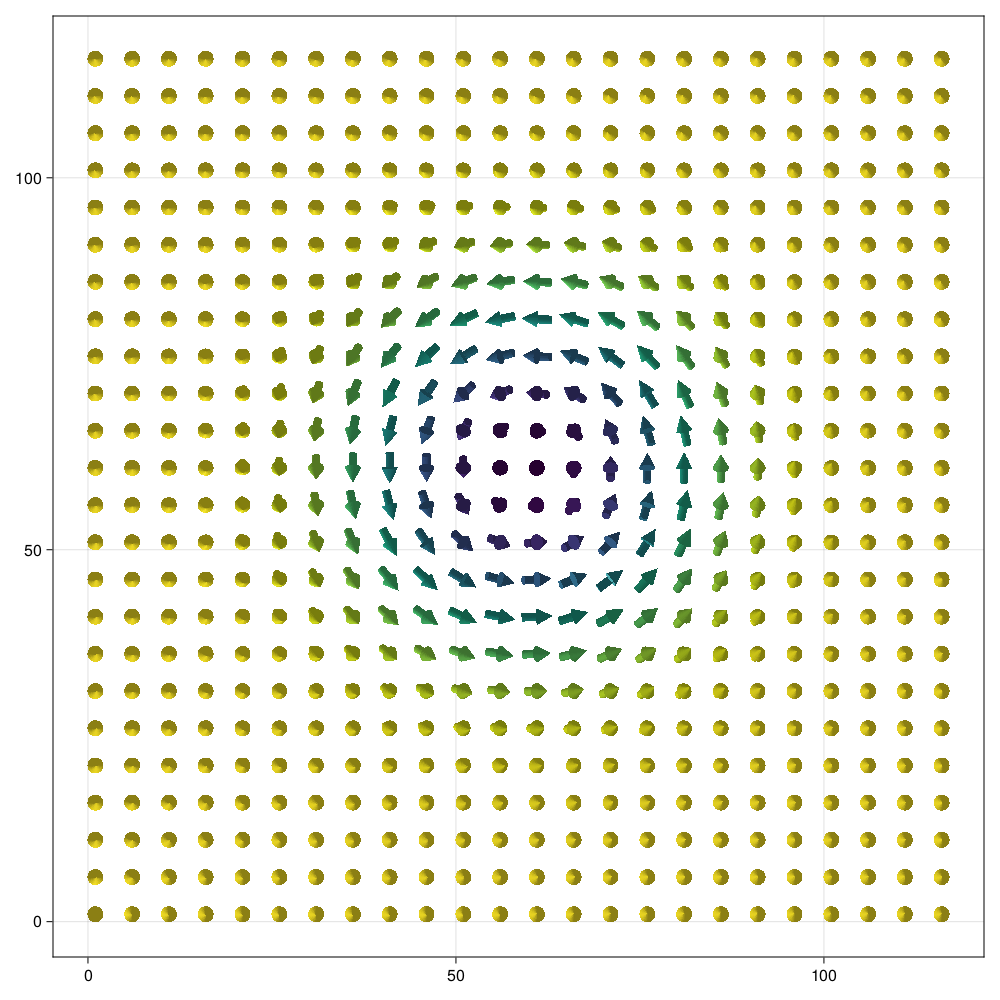

In [6]:
using CairoMakie

function plot_spatial_m()
  m = npzread("skx.npy")

  nx, ny, nz = 120, 120, 1
  points = [Point3f(i, j, 0) for i in 1:5:nx for j in 1:5:ny]

  m = reshape(m, 3, nx, ny)
  mf = [Vec3f(m[1, i, j], m[2, i,j], m[3, i,j]) for i in 1:5:nx for j in 1:5:ny]
  mz = [m[3, i, j]  for i in 1:5:nx for j in 1:5:ny]

  fig = Figure(resolution = (1000, 1000))
  ax = Axis(fig[1, 1], backgroundcolor = "white")

  arrows!(ax, points, mf, fxaa=true, # turn on anti-aliasing
          color = vec(mz), linewidth = 1, arrowsize = 2, lengthscale = 2,
          align = :center
      )


  return fig

end

plot_spatial_m()

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*